# Baseline Model Runs: Triplet Loss

This notebook contains the code used to train a Vision Transformer model using triplet margin loss. Key visualizations to analyze the model's outputs are also included.

**WARNING:** This function trains a model and saves its weights. However, these weights may not necessarily work as expected with `run_inference.py`. To avoid errors, only run `run_inference.py` with the model weights provided (`final_model.pth`) or those generated by the notebook `model_test_runs_finalized.ipynb`.

In [ ]:
#Importing packages
from torch.utils.data import DataLoader
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import pandas as pd
from chromadb import PersistentClient as PersistentClient
from chromadb.errors import InternalError as CollectionError
import os

#library functions
import src.dataloading as dataloading
import src.data_vis as data_vis
import src.model_functions as model_functions
import src.loss_functions as loss_functions
import src.models as models
from src.seeds import set_seed



d:\Projects\alertcalifornia-anomaly-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We set the seed for reproducibility, though results still vary slightly

In [2]:
g = set_seed()

## Data Loading

First, we load the data that was imported from LabelStudio. The data is split into training, validation, and testing splits, then batched into dataloaders.

In [ ]:
#Set directory to data and device for training
labels_csv = r"camera_data/coronado_hills_4pt.csv"
device = 'cuda'


load = False

#Set parameters for saving model
model_path = 'weights/'
model_name = "triplet_loss_model.pth"

#Load data and create dataloaders
data = dataloading.get_data(labels_csv, 'camera_data/images/', replace_images = False, binarize=True)
train, val, test = dataloading.get_train_val_test(data = data, output_csvs=True)
train_dataloader, val_dataloader, test_dataloader = dataloading.get_train_val_test_dataloaders(train, val, test, generator = g)

100%|██████████| 2314/2314 [00:00<00:00, 6701.13it/s]


## Model Training

Next, we instantiate a Vision Transformer model and train it on the data we loaded.

In [4]:
#Create an encoder model and load weights from Quarter 1 project
encoder = models.create_encoder()
encoder.to(device)
encoder.load_state_dict(torch.load('weights/model_weights_camera_10-27-25.pth', map_location=device, weights_only=True));

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Instantiating the training settings

In [5]:
loss_func = loss_functions.TripletMarginLoss(margin = 0.19)
optimizer = optim.Adam(encoder.parameters(), lr=1e-5) 
num_epochs = 10

Training the model

In [1]:
if load:
    encoder.load_state_dict(torch.load(os.path.join(model_path, model_name), map_location=device, weights_only=True))
    losses = []
else:
    losses = model_functions.train_model(encoder, train_data=train_dataloader, 
                                num_epochs=num_epochs, loss_func=loss_func, 
                                optimizer=optimizer, name = 'triplet_loss_model.pth', 
                                path = 'weights/', device=device)

NameError: name 'load' is not defined

Saving the embeddings generated by this model

In [8]:
#Delete old collections of embeddings if they exist

client = PersistentClient(path="embedding_data/") 

try:
    client.delete_collection(name="train_embeddings")
except Exception:
    pass

try:
    client.delete_collection(name="val_embeddings")
except Exception:
    pass

#Save new collections of embeddings for training and validation data
dataloading.save_full_embeddings(encoder, train_dataloader, 
                        "train_embeddings", persist_directory = "embedding_data/", 
                        device = device)


dataloading.save_full_embeddings(encoder, val_dataloader, 
                        "val_embeddings", persist_directory = "embedding_data/", 
                        device = device)
    
    
#Embeddings of training data, used to train the classification head
train_embeddings, train_labels, train_img_urls, train_a_ids = dataloading.load_full_embeddings(train, "train_embeddings", persist_directory = "embedding_data/")
train_embedding_dataloader = dataloading.embedding_to_dataloader(train_embeddings, train_labels, batch_size=32, generator = g)

#Embeddings of validation data, used to display results
val_embeddings, val_labels, val_img_urls, val_a_ids = dataloading.load_full_embeddings(val, "val_embeddings", persist_directory = "embedding_data/")

Visualizing the first two principal axes of the embedding space

In [ ]:
reduced_embeddings, labels = model_functions.reduce_pca(train_embeddings, train_labels, dimensions=5)

Text(0.5, 1.0, 'First two axes of embedding space generated by Triplet Loss model')

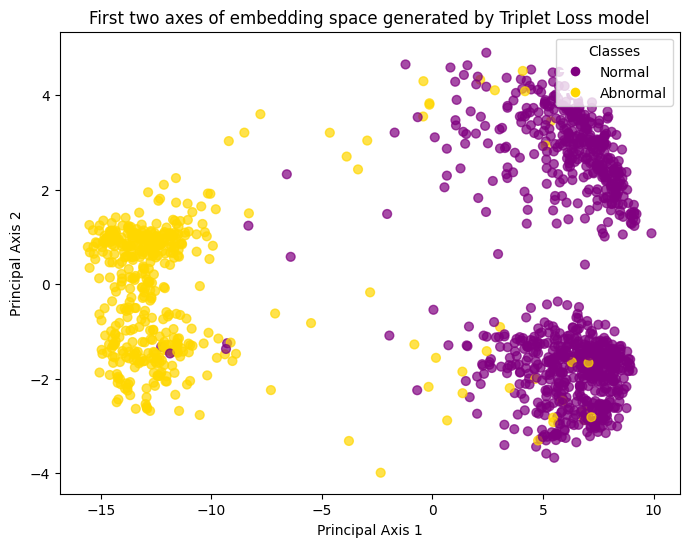

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ax = data_vis.plot_data(reduced_embeddings, labels, pcx = 1, pcy = 2, ax=ax)
ax.set_title("First two axes of embedding space generated by Triplet Loss model")

Training classification head

In [13]:
losses = []

#Instantiate classification head
classification_head = models.ClassificationHead(num_classes=2)
classification_head.to(device)

#Define criterion and optimizer for training the classification head
head_criterion = nn.CrossEntropyLoss()
head_optimizer = optim.Adam(classification_head.parameters(), lr=1e-3) # Optimize only the new head

losses = model_functions.train_classification_head(classification_head, train_embedding_dataloader, num_epochs=15, criterion=head_criterion, optimizer=head_optimizer, 
                           device=device, model_name='triplet_loss_model_head.pth', model_path = "weights/", save=True)

classification_head.eval()

Processing batches in epoch 10:  32%|███▏      | 14/44 [00:01<00:02, 10.78it/s]


KeyboardInterrupt: 

Testing classification head outputs

In [28]:
#Function to calculate accuracy of classification head on given embeddings and labels
def get_accuracy(outputs, labels):
    return (torch.argmax(outputs, dim = -1) == labels).float().mean().item()

#Convert embeddings and labels to tensors for calculating accuracy
train_embeddings_tensor = torch.Tensor(train_embeddings.to_numpy()).to(device)
val_embeddings_tensor = torch.Tensor(val_embeddings.to_numpy()).to(device)

train_labels_tensor = torch.Tensor(train_labels.to_numpy()).to(device)
val_labels_tensor = torch.Tensor(val_labels.to_numpy()).to(device)

#Obtain outputs from classification head and calculate accuracy
train_outputs = classification_head(train_embeddings_tensor)
val_outputs = classification_head(val_embeddings_tensor)

print(f"Training accuracy: {get_accuracy(train_outputs, train_labels_tensor)}")
print(f"Validation accuracy: {get_accuracy(val_outputs, val_labels_tensor)}")

Training accuracy: 0.9762247800827026
Validation accuracy: 0.9330453276634216
